# Figures for Sequential 3v Paper

In [22]:
%pip install scipy

Welcome to Command Prompt
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ----------------------- ---------------- 21.5/36.6 MB 104.6 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.6 MB 105.2 MB/s eta 0:00:01
   ---------------------------------------- 36.6/36.6 MB 68.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


The system cannot find the path specified.


## Figure 2

In [265]:
# imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit



# constants
c = 3e8
m = 88 * 1.66e-27  # Sr88 mass
kb = 1.38e-23
PI = np.pi
T = 7e-6           # Cloud temperature (5 uK)
v0 = 2 * PI * 434e12 # 689 nm frequency (used as reference)
gamma_689_rad = 2 * PI * 7.48e3

# Calculate Doppler limit
vdopp_rad = v0 * np.sqrt(8 * kb * T * np.log(2) / m / c**2)
vdopp = vdopp_rad / (2 * PI) # Hz


In [ ]:
# data for Figure 2.1
y_1v = np.array([0.00548685106776244, 0.009308752536206534, 0.02259664131295908, \
0.030622330352082498, 0.04132145095035856, 0.05076299467229629, \
0.052702854059117614, 0.05819786128758925, 0.04979127989565811, \
0.050612041480915096, 0.04943490482224261, 0.03255465551781204, \
0.020113473364293526, 0.01070628564885387, 0.000677157229459564])  # 1 photon linewidth data

y_3v = np.array([0.005040271176251144, 0.0026282707369170524, 0.0011889584437536707, 
  0.009708389956419749, 0.0, 0.007092358646527452, 
  0.00045177128439428553, 0.003784300708605921, 0.01606494774738008, 
  0.005518228939803119, 0.021699434838833277, 0.02210032594005883, 
  0.0018075674325674326, 0.0005656108597285068, 0.000871324188631881, 
  0.01973905524989366, 0.015223028669940748, 0.03409204941886204, 
  0.09463500173844688, 0.012875241597485893, 0.009087708552177758, 
  0.016841363200516175, 0.08463234895365723, 0.25152991593426305, 
  0.4424884363992948, 0.7023903192281638, 0.8924532343593577, 
  0.8723758889496718, 0.6332810122335518, 0.45822297217861563, 
  0.31914666355938787, 0.15789038078321269, 0.06533490011750881, 
  0.030497013747188752, 0.05516880005988472, 0.06014401824752723, 
  0.04740793506481334, 0.03146662895753727, 0.036369123525426136, 
  0.008459152700942479, 0.018474667531249458, 0.013274178604518566, 
  0.014063343883607048, 0.01142562288073124, 0.02078879688405905, 
  0.007335763574015242, 0.003325540710006038, 0.010791693116894895, 
  0.011151692825146201, 0.007645931672664392, 0.00543247115602141]) # 3 photon linewidth data

f_3v_MHz = np.linspace(-80, 20, len(y_3v))
f_1v_MHz = np.linspace(-70, 70, len(y_1v) ) 

pi_times1 = np.array([0.1, 0.3, 0.8, 2.4, 5, 20, 15, 10, 50]) * 1e-6
omega_1v_rad = PI/pi_times1
omega_1v = omega_1v_rad  /( 2*PI)
lw_1v_khz = np.array([3559, 987, 353, 144, 67.4, 47.4, 41.1, 47.9, 34.7]) * 2.355
f_limit1 = 1.772 * omega_1v
pb_limit1 = 1.414 * omega_1v

pi_times3 = np.array([2, 4, 6, 9.5, 22, 38, 75, 249, 900, 3000, 5000]) * 1e-6
lw_3v_khz = np.array([328, 187, 155, 77.2, 31.4, 21.8, 8.7, 2.64, 0.874, 0.247, 0.209])
omega_3v_rad = PI/pi_times3
omega_3v = omega_3v_rad  / ( 2*PI)
f_limit3 = 1.772 * omega_3v
pb_limit3 = 1.414 * omega_3v




In [120]:
omega_3v * 1e-3

array([2.50000000e+02, 1.25000000e+02, 8.33333333e+01, 5.26315789e+01,
       2.27272727e+01, 1.31578947e+01, 6.66666667e+00, 2.00803213e+00,
       5.55555556e-01, 1.66666667e-01, 1.00000000e-01])

C:\Users\Erik\AppData\Local\Temp\ipykernel_781144\3560883699.py:10: RuntimeWarning: invalid value encountered in sqrt
  return A / np.sqrt(2*PI*sigma) * np.exp(-(f-f0)**2/(2*sigma**2))


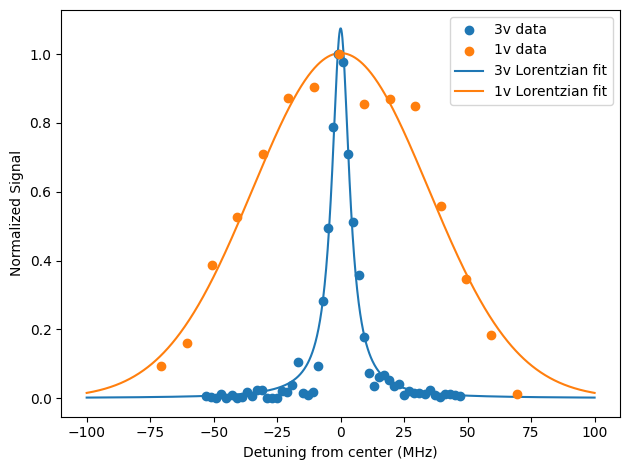

In [214]:

# calculate max values of 1 photon and 3 photon data to normalize data
y_3v_norm = y_3v / np.max(y_3v)
y_1v_norm = y_1v / np.max(y_1v)

# fit Lorentzian function and then plot data vs detunings shifted so centers are aligned in middle of plot
def lorentzian(f, f0, gamma, A):
    return A / (1 + ((f - f0) / (gamma / 2))**2)

def gaussian(f, f0, sigma, A):
    return A / np.sqrt(2*PI*sigma) * np.exp(-(f-f0)**2/(2*sigma**2))

popt_3v, _ = curve_fit(lorentzian, f_3v_MHz, y_3v_norm, p0=[-30, 10, 1.0])
popt_1v, _ = curve_fit(gaussian, f_1v_MHz, y_1v_norm, p0=[0, 50, 1.0])

f0_3v = popt_3v[0]
f0_1v = popt_1v[0]

f_3v_shifted = f_3v_MHz - f0_3v
f_1v_shifted = f_1v_MHz - f0_1v

f_fine = np.linspace(-100, 100, 1000)

plt.figure()
plt.scatter(f_3v_shifted, y_3v_norm, label='3v data', zorder=3)
plt.scatter(f_1v_shifted, y_1v_norm, label='1v data', zorder=3)
plt.plot(f_fine, lorentzian(f_fine, 0, popt_3v[1], popt_3v[2]), label='3v Lorentzian fit')
plt.plot(f_fine, gaussian(f_fine, 0, popt_1v[1], popt_1v[2]), label='1v Lorentzian fit')
plt.xlabel('Detuning from center (MHz)')
plt.ylabel('Normalized Signal')
plt.legend()
plt.tight_layout()
plt.show()

f_3v_shifted = f_3v_MHz - f0_3v
f_1v_shifted = f_1v_MHz - f0_1v
y_3v_norm
y_1v_norm
f_fine = np.linspace(-100, 100, 1000)
y_3v_fit = lorentzian(f_fine, 0, popt_3v[1], popt_3v[2])
y_1v_fit = gaussian(f_fine, 0, popt_1v[1], popt_1v[2])




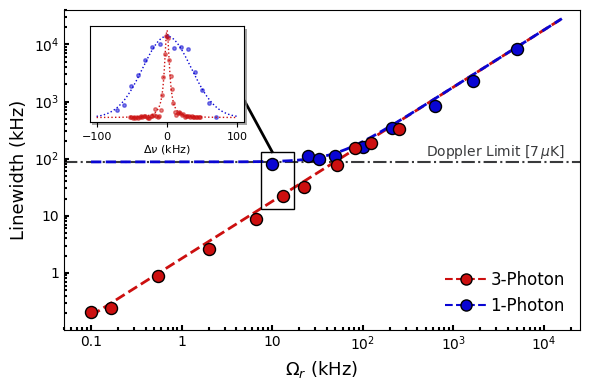

In [285]:
from matplotlib import patheffects
import matplotlib.patches as patches

color_3v = "#CC0F0F"
color_1v = "#0905D3"
color_dlimit = "#393A3C"
axis_fs = 13
marker_size = 75
theory_lw = 2


plt.rcParams.update({'font.size': 10, 'font.family': 'sans-serif'})


########### THEORY LINES ###########
rabi_freq_rad = 2 * PI * np.logspace(2, 7.2, 500) # 100 Hz to 100 MHz
rabi_freq = rabi_freq_rad / (2*PI) # 100 Hz to 100 MHz

f_limit3 = 2 * 0.89 * rabi_freq
pb_limit3 = 1.414 * rabi_freq

f_limit1 = 2 * 0.89 * rabi_freq
pb_limit1 = gamma_689_rad * np.sqrt(1 + 2 * (rabi_freq_rad / gamma_689_rad)**2) / (2*PI)

lw_1v_theory = np.sqrt(f_limit3**2 + vdopp**2)
lw_3v_theory = f_limit3

########### PLOTTING ###########
fig, ax = plt.subplots(figsize=(6, 4))


# Plot Data
ax.scatter(omega_1v / 1e3, lw_1v_khz, 
          marker='o', ec='k', fc=color_1v, s=marker_size, zorder=2)
ax.scatter(omega_3v / 1e3, lw_3v_khz, 
          marker='o', ec='k', fc=color_3v, s=marker_size, zorder=2)

# Plot Doppler Limit
ax.axhline(vdopp / 1e3, color=color_dlimit, linestyle='-.', 
           alpha=1, zorder=0)
ax.text(0.5e3, 110, r"Doppler Limit [7$\,\mu$K]", c=color_dlimit)

# Plot Theory Lines

ax.plot(rabi_freq / 1e3, lw_3v_theory / 1e3, 
          color=color_3v, linewidth=theory_lw, zorder=1, linestyle='--')
ax.plot(rabi_freq / 1e3, lw_1v_theory / 1e3, 
          color=color_1v, linewidth=theory_lw, zorder=1, linestyle='--')

plt.plot([], [], linestyle='--', marker='o', markersize=8, markeredgecolor='k', markerfacecolor=color_3v, label='3-Photon', color=color_3v)
plt.plot([], [], linestyle='--', marker='o', markersize=8, markeredgecolor='k', markerfacecolor=color_1v, label='1-Photon', color=color_1v)


########### Inset: Frequency Scans ###########

# data
# f_3v_shifted = f_3v_MHz - f0_3v
# f_1v_shifted = f_1v_MHz - f0_1v
# y_3v_norm
# y_1v_norm
# f_fine = np.linspace(-100, 100, 1000)
# y_3v_fit = lorentzian(f_fine, 0, popt_3v[1], popt_3v[2])
# y_1v_fit = gaussian(f_fine, 0, popt_1v[1], popt_1v[2])


# Create inset axes [left, bottom, width, height] in normalized figure coordinates
axins = ax.inset_axes([0.05, 0.65, 0.3, 0.3])

# # Plot inset data
axins.plot(f_1v_shifted, y_1v_norm, '.', color=color_1v, alpha=0.5, markersize=5)
axins.plot(f_fine, y_1v_fit, color=color_1v, linewidth=1, linestyle=':')

axins.plot(f_3v_shifted, y_3v_norm, '.', color=color_3v, alpha=0.5, markersize=5)
axins.plot(f_fine, y_3v_fit, color=color_3v, linewidth=1, linestyle=':')

# Formatting Inset
axins.set_yticks([]) 
axins.set_xlabel(r'$\Delta\nu$ (kHz)', fontsize=8, labelpad=1)
axins.tick_params(axis='x', labelsize=8)
# axins.set_xlim(-400, 400)
# axins.set_ylim(-0.1, 1.2)

axins.patch.set_path_effects([
    patheffects.withSimplePatchShadow(offset=(2, -2), shadow_rgbFace='gray', alpha=0.7)
])







# Formatting Main Axes
ax.set_xlabel(r'$\Omega_r$ (kHz)', fontsize=axis_fs)
ax.set_ylabel('Linewidth (kHz)', fontsize=axis_fs)
ax.set_xlim(0.05, 2.5e4)
ax.set_ylim(0.1, 4e4)
# ax.grid(True, which="both", ls="--", alpha=0.3)
ax.legend(loc='lower right', fontsize=12, frameon=False, handlelength=2.5, handletextpad=0.2)
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xticks([0.1, 1, 10, 1e2, 1e3, 1e4])
ax.set_xticklabels([0.1, 1, 10, r"$10^2$", r"$10^3$", r"$10^4$"])

ax.set_yticks([1, 10, 1e2, 1e3, 1e4])
ax.set_yticklabels([1, 10, r"$10^2$", r"$10^3$", r"$10^4$"])

ax.tick_params(axis='both', direction="in", which='both', width=1.5)

rect = patches.Rectangle((7.5, 13), 10, 120, linewidth=1, edgecolor='k', facecolor='none')
ax.add_patch(rect)
plt.plot([5, 10], [1e3, 1.32e2], c='k', lw=2)



plt.tight_layout()
plt.show()

In [ ]:
# --- Inset: Frequency Scans ---
# Create inset axes [left, bottom, width, height] in normalized figure coordinates
# axins = ax.inset_axes([0.65, 0.15, 0.3, 0.3])

# # Generate frequency axis for the inset (detuning in kHz)
# detuning = np.linspace(-500, 500, 400)

# # Sinc^2 profile for 3-photon (narrow) and Voigt/Gaussian for 1-photon (broad)
# # np.sinc(x) calculates sin(pi * x) / (pi * x)
# profile_3phot = np.sinc(detuning / 50)**2  + np.random.normal(0, 0.05, len(detuning))
# profile_1phot = np.exp(-(detuning)**2 / (2 * 150**2)) + np.random.normal(0, 0.05, len(detuning))

# # Fit lines for inset
# fit_3phot = np.sinc(detuning / 50)**2
# fit_1phot = np.exp(-(detuning)**2 / (2 * 150**2))

# # Plot inset data
# axins.plot(detuning, profile_1phot, '.', color='#D55E00', alpha=0.5, markersize=3)
# axins.plot(detuning, fit_1phot, color='#D55E00', linewidth=1.5)

# axins.plot(detuning, profile_3phot, '.', color='#0072B2', alpha=0.5, markersize=3)
# axins.plot(detuning, fit_3phot, color='#0072B2', linewidth=1.5)

# # Formatting Inset
# axins.set_yticks([]) # Hide y-axis ticks to keep it clean
# axins.set_xlabel(r'$\Delta\nu$ (kHz)', fontsize=8, labelpad=1)
# axins.tick_params(axis='x', labelsize=8)
# axins.set_xlim(-400, 400)
# axins.set_ylim(-0.1, 1.2)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- Parameters ---
pi_time = 1.9         # us
t_max = pi_time * 3   # us (1.5 full Rabi oscillations = 3 pi-times)
peak_exc = 0.9        # Maximum initial population in 3P0
tau_decay = 15.0      # Phenomenological damping time constant (us)

# --- Time Arrays ---
t_theory = np.linspace(0, t_max, 500)
t_data = np.linspace(0, t_max, 35) 

# --- Physics / Damped Population Model (Theory) ---
decay_theory = np.exp(-t_theory / tau_decay)
decay_data = np.exp(-t_data / tau_decay)

# Main states
pop_3P0_theory = (peak_exc / 2) * (1 - np.cos(np.pi * t_theory / pi_time) * decay_theory)
pop_3P1_theory = (0.04 / 2) * (1 - np.cos(np.pi * t_theory / pi_time) * decay_theory)
pop_3P2_theory = (0.02 / 2) * (1 - np.cos(np.pi * t_theory / pi_time) * decay_theory)
pop_1S0_theory = 1.0 - pop_3P0_theory - pop_3P1_theory - pop_3P2_theory

# --- Experimental Data (with noise) ---
np.random.seed(123) 
noise_level = 0.025 

pop_3P0_data = (peak_exc / 2) * (1 - np.cos(np.pi * t_data / pi_time) * decay_data) + np.random.normal(0, noise_level, len(t_data))
pop_3P1_data = (0.04 / 2) * (1 - np.cos(np.pi * t_data / pi_time) * decay_data) + np.random.normal(0, 0.008, len(t_data))
pop_3P2_data = (0.02 / 2) * (1 - np.cos(np.pi * t_data / pi_time) * decay_data) + np.random.normal(0, 0.008, len(t_data))
pop_1S0_data = 1.0 - pop_3P0_data - pop_3P1_data - pop_3P2_data + np.random.normal(0, noise_level, len(t_data))

# Clip data between 0 and 1
pop_3P0_data = np.clip(pop_3P0_data, 0, 1)
pop_1S0_data = np.clip(pop_1S0_data, 0, 1)
pop_3P1_data = np.clip(pop_3P1_data, 0, 1)
pop_3P2_data = np.clip(pop_3P2_data, 0, 1)

# --- Plotting ---
plt.rcParams.update({'font.size': 10, 'font.family': 'sans-serif'})
fig, ax = plt.subplots(figsize=(6, 4))

# Modern, colorblind-friendly palette
color_1S0 = '#1A1C20' # Dark Slate/Almost Black
color_3P0 = '#C81D25' # Bold Modern Crimson
color_3P1 = '#2154c2' # Muted Blue
color_3P2 = '#e8851c' # Muted Gold

# 1. Plot Intermediate States (Subdued & Highly Transparent)
ax.plot(t_theory, pop_3P1_theory, linestyle='--', color=color_3P1, alpha=0.55, linewidth=1.5)
ax.plot(t_data, pop_3P1_data, 'v', color=color_3P1, alpha=0.35, markersize=4)

ax.plot(t_theory, pop_3P2_theory, linestyle='--', color=color_3P2, alpha=0.55, linewidth=1.5)
ax.plot(t_data, pop_3P2_data, '^', color=color_3P2, alpha=0.35, markersize=4)

# 2. Plot Main States (Very Bold, Dotted Theory Lines)
ax.plot(t_theory, pop_1S0_theory, linestyle='--', color=color_1S0, linewidth=3.0)
ax.plot(t_data, pop_1S0_data, 'o', markeredgecolor='k', markerfacecolor='#555555', markersize=6)

ax.plot(t_theory, pop_3P0_theory, linestyle='--', color=color_3P0, linewidth=3.0)
ax.plot(t_data, pop_3P0_data, 's', markeredgecolor='k', markerfacecolor=color_3P0, markersize=6)

# Formatting Main Axes
ax.set_xlabel(r'Pulse Duration ($\mu$s)', weight='bold')
ax.set_ylabel('State Population', weight='bold')
ax.set_xlim(0, t_max)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, which="major", ls="--", alpha=0.3)

# --- Succinct Legend ---
legend_elements = [
    Line2D([0], [0], color=color_1S0, lw=3.0, label=r'$^1S_0$'),
    Line2D([0], [0], color=color_3P0, lw=3.0, label=r'$^3P_0$'),
    Line2D([0], [0], color=color_3P1, lw=2, alpha=0.7, label=r'$^3P_1$'),
    Line2D([0], [0], color=color_3P2, lw=2, alpha=0.7, label=r'$^3P_2$'),
    Line2D([0], [0], color='k', linestyle='--', lw=2, label='Theory'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='k', markeredgecolor='k', markersize=6, label='Data')
]

# Moved legend slightly to accommodate the top-right inset
ax.legend(handles=legend_elements, loc='center right', fontsize=8, framealpha=0.9, ncol=2)

# --- Inset: Atom Cloud Images & Pointer ---
# Moved to Top Right
axins_img = ax.inset_axes([0.02, 0.78, 0.25, 0.2])
axins_img.set_xticks([])
axins_img.set_yticks([])
axins_img.text(0.5, 0.5, 'Cloud Image', ha='center', va='center', fontsize=9, color='gray', weight='bold')
axins_img.set_facecolor('#f4f4f4')

# Point arrow to the 3-pi peak (t = 5.7 us)
third_pi_time = pi_time * 3
peak_y_3 = pop_3P0_theory[np.argmin(np.abs(t_theory - third_pi_time))]
ax.annotate('', xy=(third_pi_time, peak_y_3 + 0.02), xytext=(third_pi_time, 0.70),
            arrowprops=dict(arrowstyle="->", color=color_3P0, lw=1.5, ls='--'))

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters & Decay Models ---
tau_1 = 3.5      # 1-photon 1/e time in us
tau_3 = 1800.0   # 3-photon 1/e time in us
c0_1 = 0.82      # Initial contrast 1-photon
c0_3 = 0.65      # Initial contrast 3-photon

def contrast_decay(t, c0, tau):
    return c0 * np.exp(-(t / tau)**2)

# --- Time Arrays ---
t_1_theory = np.logspace(0, 1.2, 100)
t_1_data = np.logspace(0, 0.8, 8)

t_3_theory = np.logspace(1.5, 3.6, 100)
t_3_data = np.logspace(1.9, 3.4, 12)

# --- Generate Data ---
np.random.seed(42)
c_1_theory = contrast_decay(t_1_theory, c0_1, tau_1)
c_1_data = contrast_decay(t_1_data, c0_1, tau_1) + np.random.normal(0, 0.02, len(t_1_data))

c_3_theory = contrast_decay(t_3_theory, c0_3, tau_3)
c_3_data = contrast_decay(t_3_data, c0_3, tau_3) + np.random.normal(0, 0.02, len(t_3_data))

# Operating point for the star
t_star = 1000.0
c_star = contrast_decay(t_star, c0_3, tau_3)

# --- Plotting ---
# BUMP UP GLOBAL FONT SIZES for a punchier look
plt.rcParams.update({'font.size': 10, 'font.family': 'sans-serif'})
fig, ax = plt.subplots(figsize=(5.5, 2.5)) # Slightly narrower to compress horizontal dead space

color_1phot = '#0072B2'
color_3phot = '#C81D25'
color_star = '#E69F00' 

# 1-Photon Plot (Thicker lines, larger markers)
ax.plot(t_1_theory, c_1_theory, linestyle=':', color=color_1phot, linewidth=3.5)
ax.plot(t_1_data, c_1_data, 'o', markeredgecolor='k', markerfacecolor=color_1phot, markersize=8)

# 3-Photon Plot (Thicker lines, larger markers)
ax.plot(t_3_theory, c_3_theory, linestyle=':', color=color_3phot, linewidth=3.5)
ax.plot(t_3_data, c_3_data, 's', markeredgecolor='k', markerfacecolor=color_3phot, markersize=8)

# Operating Point Star 
ax.plot(t_star, c_star, '*', markeredgecolor='k', markerfacecolor=color_star, 
        markersize=13, zorder=5)

# Annotation for the star (Tucked closer to the curve)
# ax.annotate('1 ms\nOperating\nPoint', 
#             xy=(t_star, c_star), 
#             xytext=(t_star * 0.4, c_star * 0.4),
#             arrowprops=dict(arrowstyle="-|>", color='dimgray', lw=1.2),
#             fontsize=10, color='dimgray', ha='center', weight='bold')

# Formatting Axes 
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'Ramsey delay duration ($\mu$s)', weight='bold', fontsize=13)
ax.set_ylabel('Contrast', weight='bold', fontsize=13)

# TIGHTER LIMITS to fill the space
ax.set_xlim(1, 4000) 
ax.set_ylim(0.04, 1.1)
ax.grid(True, which="major", ls="--", alpha=0.3) 

# Clean up log y-axis ticks
ax.set_yticks([0.1, 1.0])
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())

# Direct Legend Labeling (Moved to perfectly fill the structural voids)
ax.text(3.5, 0.4, '1-photon', color=color_1phot, weight='bold', fontsize=14)
ax.text(120, 0.3, '3-photon', color=color_3phot, weight='bold', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- Setup Figure ---
plt.rcParams.update({'font.size': 13, 'font.family': 'sans-serif'})
fig, ax = plt.subplots(figsize=(7, 1.7)) # Wide and short aspect ratio

# --- Colors matching previous panels ---
color_cooling = '#888888'  # Gray
edge_cooling = '#333333'   # Dark Slate
color_pi = '#C81D25'       # Bold Modern Crimson
color_detect = '#0072B2'   # Muted Blue

# --- Helper Function to Draw Pulses ---
def draw_pulse(ax, x, width, height, label, edgecolor, facecolor, text_rot=0, fontsize=14):
    # Add the rectangle block
    rect = patches.Rectangle((x, 0), width, height, linewidth=3.0, 
                             edgecolor=edgecolor, facecolor=facecolor, zorder=3)
    ax.add_patch(rect)
    # Add the centered text
    ax.text(x + width/2, height/2, label, ha='center', va='center', 
            rotation=text_rot, color='black', weight='bold', fontsize=fontsize, zorder=4)

# --- Define Sequence Timing (Relative X Coordinates) ---
h = 1.0 # Standard pulse height

# 1. Cooling Block (Filled)
draw_pulse(ax, x=0, width=2.5, height=h, label='Cooling', 
           edgecolor=color_cooling, facecolor=color_cooling, fontsize=14)

# 2. First Pi/2 Pulse (Unfilled, red border)
draw_pulse(ax, x=2.7, width=0.8, height=h, label=r'$\frac{\pi}{2}$', 
           edgecolor=color_pi, facecolor='#C81D2515', fontsize=16) # 15 is hex for ~8% opacity

# 3. First Pi_R Pulse
draw_pulse(ax, x=3.6, width=1.0, height=h, label=r'$\pi_R$', 
           edgecolor=color_pi, facecolor='#C81D2515', fontsize=15)

# 4. Tau Gap (Center = 5.45)
# Draw double-headed arrow for tau
ax.annotate('', xy=(4.7, h/2), xytext=(6.2, h/2),
            arrowprops=dict(arrowstyle="<->", color='black', lw=2.0))
# Place tau text with a white background so it breaks the arrow cleanly
ax.text(5.45, h/2, r'$\tau$', ha='center', va='center', fontsize=16, weight='bold',
        bbox=dict(facecolor='white', edgecolor='none', pad=2))

# 5. Second Pi_R Pulse
draw_pulse(ax, x=6.3, width=1.0, height=h, label=r'$\pi_R$', 
           edgecolor=color_pi, facecolor='#C81D2515', fontsize=15)

# 6. Second Pi/2 Pulse with Phase
draw_pulse(ax, x=7.4, width=1.0, height=h, label=r'$\frac{\pi}{2}, \phi$', 
           edgecolor=color_pi, facecolor='#C81D2515', fontsize=14)

# 7. Detection Block
draw_pulse(ax, x=8.6, width=1.0, height=h, label='Detect', 
           edgecolor=color_detect, facecolor='#0072B215', text_rot=90, fontsize=10)

# --- Draw the "Free Space" Bracket ---
bracket_y = h + 0.15
bracket_start = 2.7
bracket_end = 9.6
bracket_tick = 0.08

# Main horizontal line
ax.plot([bracket_start, bracket_end], [bracket_y, bracket_y], color='k', lw=2.0)
# Vertical drop ticks at the ends
ax.plot([bracket_start, bracket_start], [bracket_y, bracket_y - bracket_tick], color='k', lw=2.0)
ax.plot([bracket_end, bracket_end], [bracket_y, bracket_y - bracket_tick], color='k', lw=2.0)
# Bracket Text
ax.text((bracket_start + bracket_end)/2, bracket_y + 0.08, 'Free space', 
        ha='center', va='bottom', fontsize=14, weight='bold')

# --- Draw Custom Axes (Arrows) ---
# X-axis (Time)
ax.annotate('', xy=(10.0, 0), xytext=(-0.5, 0),
            arrowprops=dict(arrowstyle="->", color='black', lw=2.5))
ax.text(9.8, -0.15, 'Time', ha='right', va='top', fontsize=14, weight='bold')

# Y-axis (Intensity)
ax.annotate('', xy=(-0.5, h + 0.5), xytext=(-0.5, 0),
            arrowprops=dict(arrowstyle="->", color='black', lw=2.5))
ax.text(-0.7, h + 0.4, 'Intensity', ha='right', va='top', rotation=90, fontsize=14, weight='bold')

# --- Final Formatting ---
# Hide all standard spines and ticks
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

# Set limits to give breathing room around the sequence
ax.set_xlim(-1.5, 10.5)
ax.set_ylim(-0.3, h + 0.6)

plt.tight_layout()
plt.show()